# Разведочный анализ данных (EDA)



In [1]:
# Установка библиотек для Google Colab
!pip -q install xgboost lightgbm openpyxl seaborn


In [6]:
# Загрузка исходного файла с данными

import os
from google.colab import files

DATA_PATH = '/content/drug_data.xlsx'

if not os.path.exists(DATA_PATH):
    uploaded = files.upload()
    if 'drug_data.xlsx' not in uploaded:

        first_file = next(iter(uploaded.keys()))
        os.rename(first_file, DATA_PATH)

os.makedirs('reports', exist_ok=True)
os.makedirs('models', exist_ok=True)
print(f'Файл данных: {DATA_PATH}')
print('Папки reports/ и models/ готовы')


Файл данных: /content/drug_data.xlsx
Папки reports/ и models/ готовы


## Основной код

РАЗВЕДОЧНЫЙ АНАЛИЗ ДАННЫХ ХИМИЧЕСКИХ СОЕДИНЕНИЙ

1. ОБЩАЯ ИНФОРМАЦИЯ О ДАТАСЕТЕ
----------------------------------------
Размер датасета: 1001 строк, 214 столбцов
Память: 1.6 MB
Целевые переменные: ['IC50', 'CC50', 'SI']
Количество признаков: 210

Обнаружено 36 пропущенных значений. Заполнение медианой...
Заполнение пропущенных значений завершено.

Пропущенных значений нет ✓

2. АНАЛИЗ ЦЕЛЕВЫХ ПЕРЕМЕННЫХ
----------------------------------------
Описательная статистика:
           IC50      CC50         SI
count  1001.000  1001.000   1001.000
mean    222.805   589.111     72.509
std     402.170   642.868    684.483
min       0.004     0.701      0.011
25%      12.515    99.999      1.433
50%      46.585   411.039      3.846
75%     224.976   894.089     16.567
max    4128.529  4538.976  15620.599

ИНТЕРПРЕТАЦИЯ ПЕРЕМЕННЫХ:
IC50 - концентрация препарата, подавляющая 50% вирусной репликации
CC50 - концентрация препарата, токсичная для 50% клеток
SI - селективный индекс (CC50/IC50), показа

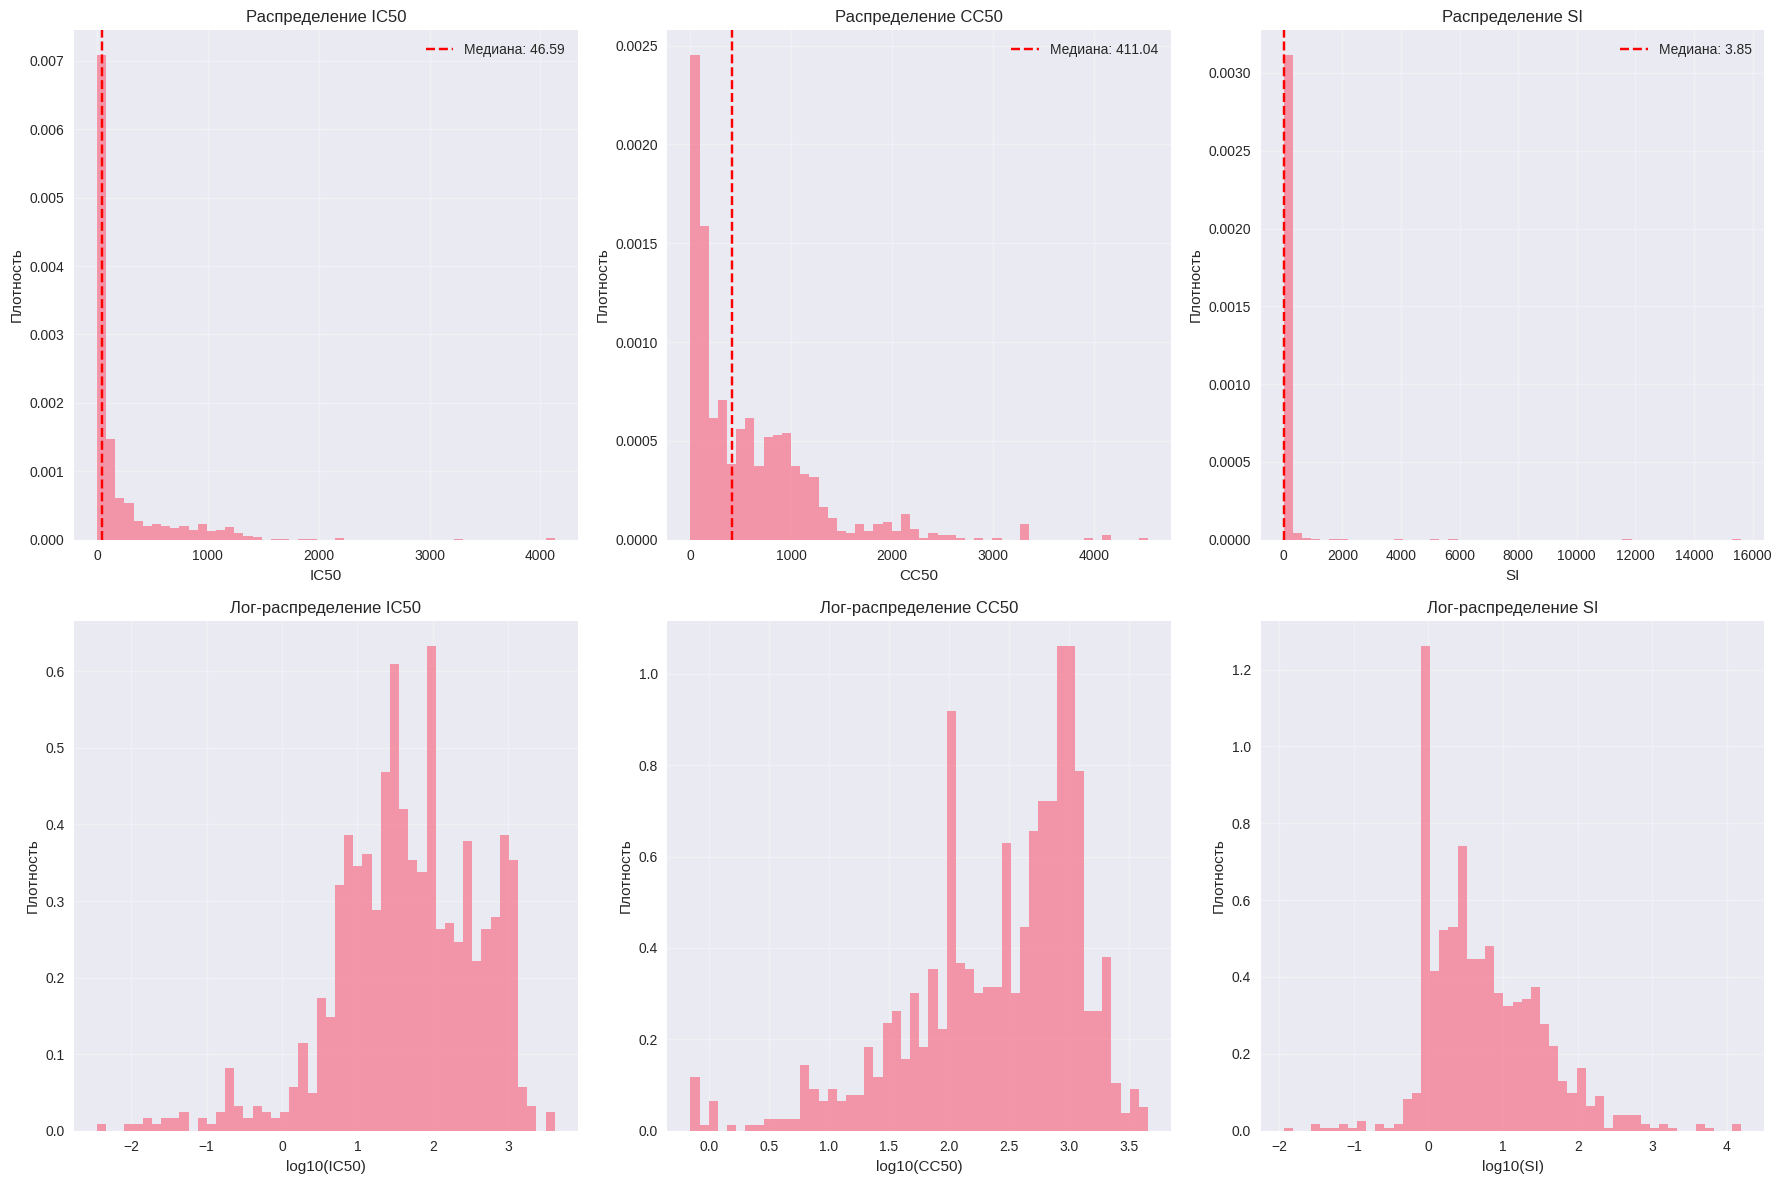


3. ТЕСТЫ НА НОРМАЛЬНОСТЬ РАСПРЕДЕЛЕНИЯ
----------------------------------------
IC50: p-value = 1.12e-43, не нормальное распределение
CC50: p-value = 5.76e-33, не нормальное распределение
SI: p-value = 1.96e-56, не нормальное распределение

4. АНАЛИЗ ПРИЗНАКОВ
----------------------------------------
Количество признаков: 210
Типы данных:
int64      106
float64    104
Name: count, dtype: int64

Статистика признаков:
Среднее количество уникальных значений: 222.1
Признаков с константными значениями: 18
Бинарных признаков (0/1): 30
Константные признаки для удаления: ['NumRadicalElectrons', 'SMR_VSA8', 'SlogP_VSA9', 'fr_N_O', 'fr_SH', 'fr_azide', 'fr_barbitur', 'fr_benzodiazepine', 'fr_diazo', 'fr_dihydropyridine', 'fr_isocyan', 'fr_isothiocyan', 'fr_lactam', 'fr_nitroso', 'fr_phos_acid', 'fr_phos_ester', 'fr_prisulfonamd', 'fr_thiocyan']

Высококоррелированные пары (r > 0.95): 91
  MaxAbsEStateIndex - MaxEStateIndex: 1.000
  MolWt - HeavyAtomMolWt: 0.997
  MolWt - ExactMolWt: 1.000
  Mol

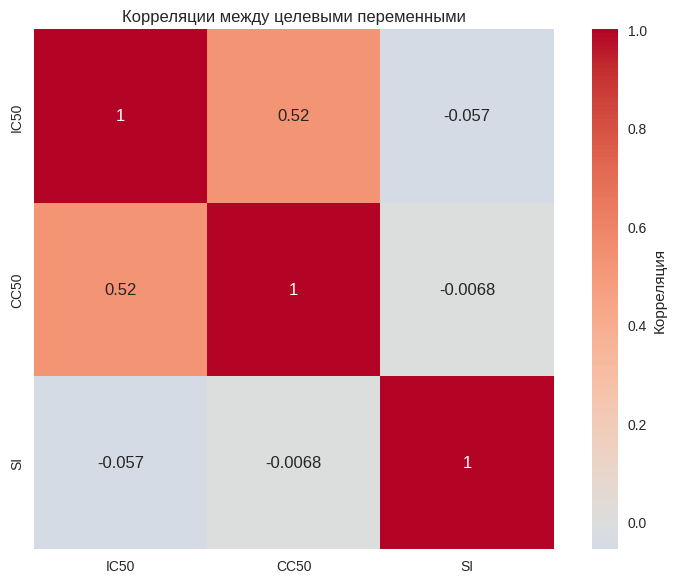


6. АНАЛИЗ ВЗАИМНОЙ ИНФОРМАЦИИ
----------------------------------------
Топ-10 признаков по взаимной информации:

IC50:
   9. ExactMolWt                     | MI = 0.4075
   7. MolWt                          | MI = 0.4068
  30. Chi0                           | MI = 0.3991
  33. Chi1                           | MI = 0.3446
   8. HeavyAtomMolWt                 | MI = 0.3387
  31. Chi0n                          | MI = 0.3369
  23. BCUT2D_LOGPHI                  | MI = 0.3330
  20. BCUT2D_MWLOW                   | MI = 0.3305
  15. MinAbsPartialCharge            | MI = 0.3296
  12. MaxPartialCharge               | MI = 0.3271

CC50:
   7. MolWt                          | MI = 1.3689
   9. ExactMolWt                     | MI = 1.3687
   8. HeavyAtomMolWt                 | MI = 1.0148
  47. LabuteASA                      | MI = 0.8564
  30. Chi0                           | MI = 0.8439
  33. Chi1                           | MI = 0.7945
  10. NumValenceElectrons            | MI = 0.7779
  44. 

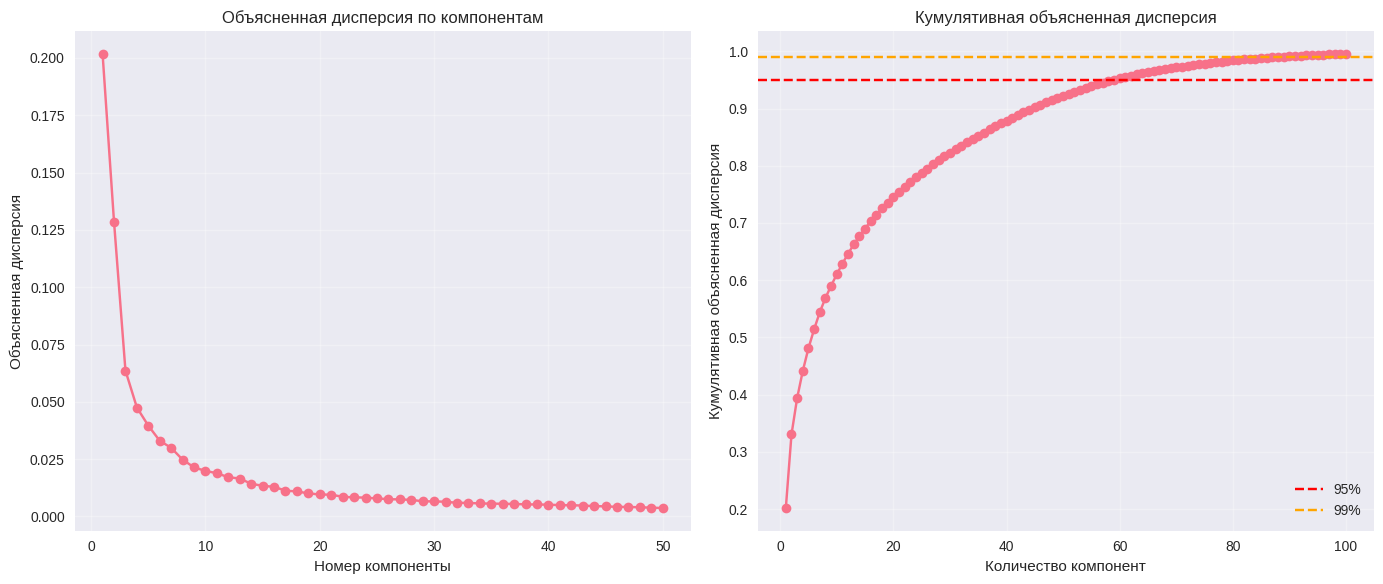


8. АНАЛИЗ ВЫБРОСОВ
----------------------------------------
IC50:
  Выбросов: 147 (14.7%)者に 1001) 
  Границы: [-306.18, 543.67]
  Диапазон значений: [0.00, 4128.53]
CC50:
  Выбросов: 39 (3.9%)者に 1001) 
  Границы: [-1091.14, 2085.22]
  Диапазон значений: [0.70, 4538.98]
SI:
  Выбросов: 125 (12.5%)者に 1001) 
  Границы: [-21.27, 39.27]
  Диапазон значений: [0.01, 15620.60]


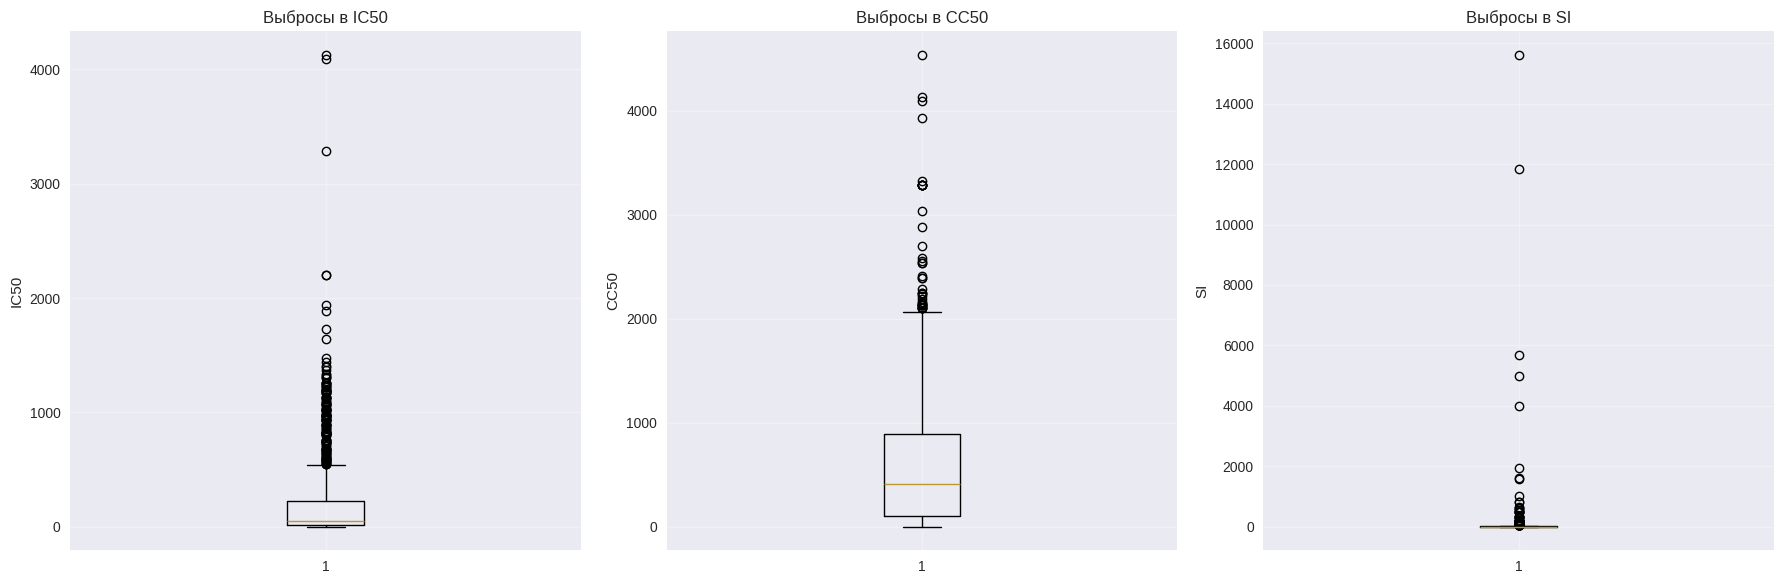


9. ИТОГОВЫЙ ОТЧЕТ EDA
ДАТАСЕТ:
  • Размер: 1001 образцов × 210 признаков
  • Пропущенные значения: отсутствуют ✓
  • Типы данных: числовые (int64, float64)

ЦЕЛЕВЫЕ ПЕРЕМЕННЫЕ:
  • IC50: [0.00, 4128.53], медиана = 46.59
    Выбросов: 147 (14.7%) из 1001 образцов
  • CC50: [0.70, 4538.98], медиана = 411.04
    Выбросов: 39 (3.9%) из 1001 образцов
  • SI: [0.01, 15620.60], медиана = 3.85
    Выбросов: 125 (12.5%) из 1001 образцов

ПРИЗНАКИ:
  • Константных признаков: 18
  • Высококоррелированных пар (r>0.95): 91
  • Бинарных признаков: 30

РЕКОМЕНДАЦИИ ДЛЯ МОДЕЛИРОВАНИЯ:
  1. Удалить константные признаки
  2. Рассмотреть удаление высококоррелированных признаков
  3. Применить логарифмическое преобразование к целевым переменным (по результатам анализа распределений)
  4. Использовать стандартизацию признаков
  5. Рассмотреть PCA для снижения размерности
  6. Обработать выбросы (робастные модели или трансформации, возможно, удаление для некоторых задач)

EDA ЗАВЕРШЕН!
Графики сохранены в 

In [7]:

"""
Разведочный анализ данных (EDA) для курсовой работы по машинному обучению
Тема: Прогнозирование эффективности химических соединений против гриппа


"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_regression
import warnings
warnings.filterwarnings('ignore')

# Настройка графиков
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
sns.set_palette("husl")

def load_and_explore_data():
    """Загрузка и первичное изучение данных"""
    print("="*60)
    print("РАЗВЕДОЧНЫЙ АНАЛИЗ ДАННЫХ ХИМИЧЕСКИХ СОЕДИНЕНИЙ")
    print("="*60)

    # Загрузка данных
    df = pd.read_excel(DATA_PATH)

    print(f"\n1. ОБЩАЯ ИНФОРМАЦИЯ О ДАТАСЕТЕ")
    print("-"*40)
    print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")
    print(f"Память: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

    # Переименуем целевые столбцы для удобства
    target_mapping = {
        'IC50, mM': 'IC50',
        'CC50, mM': 'CC50'
    }
    df = df.rename(columns=target_mapping)

    # Удалим индексный столбец если он есть
    if 'Unnamed: 0' in df.columns:
        df = df.drop('Unnamed: 0', axis=1)

    # Расчет 'SI' после переименования IC50 и CC50
    # Добавим небольшой эпсилон к IC50, чтобы избежать деления на ноль
    df['SI'] = df['CC50'] / (df['IC50'] + 1e-9)

    target_vars_list = ['IC50', 'CC50', 'SI']
    print(f"Целевые переменные: {target_vars_list}")
    print(f"Количество признаков: {df.shape[1] - len(target_vars_list)}")

    # Обработка пропущенных значений (заполнение числовых столбцов медианой)
    initial_missing_count = df.isnull().sum().sum()
    if initial_missing_count > 0:
        print(f"\nОбнаружено {initial_missing_count} пропущенных значений. Заполнение медианой...")
        for col in df.columns:
            if df[col].isnull().sum() > 0 and pd.api.types.is_numeric_dtype(df[col]):
                median_val = df[col].median()
                df[col] = df[col].fillna(median_val)
        print("Заполнение пропущенных значений завершено.")

    # Повторная проверка пропущенных значений после обработки
    missing_values = df.isnull().sum()
    if missing_values.sum() > 0:
        print(f"\nПропущенные значения после обработки: {missing_values.sum()}")
        print(missing_values[missing_values > 0])
    else:
        print("\nПропущенных значений нет ✓")

    return df

def analyze_target_variables(df):
    """Анализ целевых переменных IC50, CC50, SI"""
    print(f"\n2. АНАЛИЗ ЦЕЛЕВЫХ ПЕРЕМЕННЫХ")
    print("-"*40)

    target_vars = ['IC50', 'CC50', 'SI']

    # Статистика
    print("Описательная статистика:")
    stats_df = df[target_vars].describe().round(3)
    print(stats_df)

    # Информация об IC50, CC50, SI
    print(f"\nИНТЕРПРЕТАЦИЯ ПЕРЕМЕННЫХ:")
    print(f"IC50 - концентрация препарата, подавляющая 50% вирусной репликации")
    print(f"CC50 - концентрация препарата, токсичная для 50% клеток")
    print(f"SI - селективный индекс (CC50/IC50), показатель безопасности")
    print(f"     SI > 1: препарат безопаснее")
    print(f"     SI > 10: высокая селективность")

    # Проверка связи SI = CC50/IC50
    calculated_SI = df['CC50'] / df['IC50']
    correlation = np.corrcoef(df['SI'], calculated_SI)[0,1]
    print(f"\nПроверка формулы SI = CC50/IC50:")
    print(f"Корреляция между SI и CC50/IC50: {correlation:.6f}")
    if correlation > 0.999:
        print(" Формула подтверждена")
    else:
        print(" Возможно SI рассчитывается по-другому")

    # Медианы для классификационных задач
    print(f"\nМедианные значения (пороги для классификации):")
    for var in target_vars:
        median_val = df[var].median()
        print(f"{var}: {median_val:.3f}")

    print(f"\nДополнительный порог SI > 8: {(df['SI'] > 8).sum()} образцов ({(df['SI'] > 8).mean()*100:.1f}%)")

    # Визуализация распределений
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    for i, var in enumerate(target_vars):
        # Гистограмма
        axes[0, i].hist(df[var], bins=50, alpha=0.7, density=True)
        axes[0, i].axvline(df[var].median(), color='red', linestyle='--', label=f'Медиана: {df[var].median():.2f}')
        axes[0, i].set_title(f'Распределение {var}')
        axes[0, i].set_xlabel(var)
        axes[0, i].set_ylabel('Плотность')
        axes[0, i].legend()
        axes[0, i].grid(True, alpha=0.3)

        # Логарифмическая гистограмма
        axes[1, i].hist(np.log10(df[var] + 1e-6), bins=50, alpha=0.7, density=True)
        axes[1, i].set_title(f'Лог-распределение {var}')
        axes[1, i].set_xlabel(f'log10({var})')
        axes[1, i].set_ylabel('Плотность')
        axes[1, i].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('reports/target_variables_distributions.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Тест на нормальность (Shapiro-Wilk для выборки до 5000)
    print(f"\n3. ТЕСТЫ НА НОРМАЛЬНОСТЬ РАСПРЕДЕЛЕНИЯ")
    print("-"*40)

    for var in target_vars:
        # Тест Шапиро-Уилка

        # Если len(df[var]) < 2, тест не может быть выполнен.
        sample_size = min(len(df[var]), 1000) # Выборка 1000 для быстроты, но не больше чем есть данных
        if sample_size > 1:
            statistic, p_value = stats.shapiro(df[var].sample(sample_size, random_state=42)) # Добавил random_state для воспроизводимости
            print(f"{var}: p-value = {p_value:.2e}, ", end="")
            if p_value > 0.05:
                print("нормальное распределение")
            else:
                print("не нормальное распределение")
        else:
            print(f"{var}: Недостаточно данных ({sample_size}) для теста Шапиро-Уилка.")

    return df

def analyze_features(df):
    """Анализ признаков"""
    print(f"\n4. АНАЛИЗ ПРИЗНАКОВ")
    print("-"*40)

    feature_cols = [col for col in df.columns if col not in ['IC50', 'CC50', 'SI']]
    features_df = df[feature_cols]

    print(f"Количество признаков: {len(feature_cols)}")
    print(f"Типы данных:")
    print(features_df.dtypes.value_counts())

    # Статистика по признакам
    print(f"\nСтатистика признаков:")
    print(f"Среднее количество уникальных значений: {features_df.nunique().mean():.1f}")
    print(f"Признаков с константными значениями: {(features_df.nunique() == 1).sum()}")
    print(f"Бинарных признаков (0/1): {((features_df.nunique() == 2) & (features_df.min() >= 0) & (features_df.max() <= 1)).sum()}")

    # Константные признаки
    constant_features = features_df.columns[features_df.nunique() == 1]
    if len(constant_features) > 0:
        print(f"Константные признаки для удаления: {list(constant_features)}")

    # Высококоррелированные признаки
    # Убедитесь, что features_df не пуст и имеет более одного столбца для корреляции
    if not features_df.empty and features_df.shape[1] > 1:
        corr_matrix = features_df.corr().abs()
        upper_triangle = np.triu(np.ones_like(corr_matrix), k=1)
        high_corr_pairs = np.where((corr_matrix > 0.95) & upper_triangle)

        if len(high_corr_pairs[0]) > 0:
            print(f"\nВысококоррелированные пары (r > 0.95): {len(high_corr_pairs[0])}")
            for i in range(min(5, len(high_corr_pairs[0]))):  # Показываем первые 5
                idx1, idx2 = high_corr_pairs[0][i], high_corr_pairs[1][i]
                corr_val = corr_matrix.iloc[idx1, idx2]
                print(f"  {features_df.columns[idx1]} - {features_df.columns[idx2]}: {corr_val:.3f}")
    else:
        print("\nНедостаточно признаков для корреляционного анализа.")

    return features_df

def correlation_analysis(df):
    """Анализ корреляций признаков с целевыми переменными"""
    print(f"\n5. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ")
    print("-"*40)

    target_vars = ['IC50', 'CC50', 'SI']
    feature_cols = [col for col in df.columns if col not in target_vars]

    # Корреляции между целевыми переменными
    target_corr = df[target_vars].corr()
    print("Корреляции между целевыми переменными:")
    print(target_corr.round(3))

    # Топ-10 признаков по корреляции с каждой целевой переменной
    print(f"\nТОП-10 ПРИЗНАКОВ ПО КОРРЕЛЯЦИИ С ЦЕЛЕВЫМИ ПЕРЕМЕННЫМИ:")

    if not df[feature_cols].empty:
        for target in target_vars:
            correlations = df[feature_cols].corrwith(df[target]).abs().sort_values(ascending=False)
            top_features = correlations.head(10)

            print(f"\n{target}:")
            for i, (feature, corr) in enumerate(top_features.items(), 1):
                print(f"  {i:2d}. {feature[:30]:<30} | r = {corr:.3f}")
    else:
        print("\nНедостаточно признаков для корреляционного анализа.")


    # Создание тепловой карты корреляций между целевыми переменными
    plt.figure(figsize=(8, 6))
    sns.heatmap(target_corr, annot=True, cmap='coolwarm', center=0,
                square=True, cbar_kws={'label': 'Корреляция'})
    plt.title('Корреляции между целевыми переменными')
    plt.tight_layout()
    plt.savefig('reports/target_correlations.png', dpi=300, bbox_inches='tight')
    plt.show()

    return df

def mutual_information_analysis(df):
    """Анализ взаимной информации"""
    print(f"\n6. АНАЛИЗ ВЗАИМНОЙ ИНФОРМАЦИИ")
    print("-"*40)

    target_vars = ['IC50', 'CC50', 'SI']
    feature_cols = [col for col in df.columns if col not in target_vars]

    print("Топ-10 признаков по взаимной информации:")

    if not df[feature_cols].empty:
        features = df[feature_cols]
        for target in target_vars:
            y = df[target]
            # mutual_info_regression не работает с NaN, поэтому убедитесь, что в features нет NaN
            # На предыдущем шаге мы уже заполнили пропущенные значения.
            mi_scores = mutual_info_regression(features, y, random_state=42)

            # Создаем DataFrame для сортировки
            mi_df = pd.DataFrame({
                'feature': feature_cols,
                'mutual_info': mi_scores
            }).sort_values('mutual_info', ascending=False)

            print(f"\n{target}:")
            for i, row in mi_df.head(10).iterrows():
                print(f"  {i+1:2d}. {row['feature'][:30]:<30} | MI = {row['mutual_info']:.4f}") # row.name+1 is not correct here, use i+1.
    else:
        print("\nНедостаточно признаков для анализа взаимной информации.")

def dimensionality_analysis(df):
    """Анализ размерности данных с помощью PCA"""
    print(f"\n7. АНАЛИЗ РАЗМЕРНОСТИ (PCA)")
    print("-"*40)

    target_vars = ['IC50', 'CC50', 'SI']
    feature_cols = [col for col in df.columns if col not in target_vars]

    if not feature_cols:
        print("Недостаточно признаков для проведения PCA.")
        return

    # Стандартизация
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(df[feature_cols])

    # PCA
    pca = PCA()
    pca.fit(features_scaled)

    # Кумулятивная объясненная дисперсия
    cumvar = np.cumsum(pca.explained_variance_ratio_)

    # Находим количество компонент для объяснения 95% дисперсии
    n_components_95 = np.argmax(cumvar >= 0.95) + 1 if any(cumvar >= 0.95) else len(cumvar)
    n_components_99 = np.argmax(cumvar >= 0.99) + 1 if any(cumvar >= 0.99) else len(cumvar)

    print(f"Исходное количество признаков: {len(feature_cols)}")
    print(f"Компонент для 95% дисперсии: {n_components_95}")
    print(f"Компонент для 99% дисперсии: {n_components_99}")
    # Проверка, чтобы избежать IndexError, если компонент меньше 10
    if len(cumvar) > 9:
        print(f"Первые 10 компонент объясняют: {cumvar[9]:.1%} дисперсии")
    elif len(cumvar) > 0:
        print(f"Все {len(cumvar)} компонент объясняют: {cumvar[-1]:.1%} дисперсии")
    else:
        print("Нет компонент для объяснения дисперсии.")


    # График объясненной дисперсии
    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.plot(range(1, min(51, len(cumvar)+1)), pca.explained_variance_ratio_[:50], 'o-')
    plt.xlabel('Номер компоненты')
    plt.ylabel('Объясненная дисперсия')
    plt.title('Объясненная дисперсия по компонентам')
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(range(1, min(101, len(cumvar)+1)), cumvar[:100], 'o-')
    plt.axhline(y=0.95, color='r', linestyle='--', label='95%')
    plt.axhline(y=0.99, color='orange', linestyle='--', label='99%')
    plt.xlabel('Количество компонент')
    plt.ylabel('Кумулятивная объясненная дисперсия')
    plt.title('Кумулятивная объясненная дисперсия')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('reports/pca_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

def outlier_analysis(df):
    """Анализ выбросов"""
    print(f"\n8. АНАЛИЗ ВЫБРОСОВ")
    print("-"*40)

    target_vars = ['IC50', 'CC50', 'SI']

    # Анализ выбросов для целевых переменных
    outlier_results = {}

    for var in target_vars:
        data = df[var]
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = data[(data < lower_bound) | (data > upper_bound)]
        outlier_results[var] = {
            'count': len(outliers),
            'percentage': len(outliers) / len(data) * 100,
            'bounds': (lower_bound, upper_bound)
        }

        print(f"{var}:")
        print(f"  Выбросов: {len(outliers)} ({len(outliers)/len(data)*100:.1f}%)者に {len(data)}) ")
        print(f"  Границы: [{lower_bound:.2f}, {upper_bound:.2f}]")
        print(f"  Диапазон значений: [{data.min():.2f}, {data.max():.2f}]")

    # Визуализация выбросов
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for i, var in enumerate(target_vars):
        axes[i].boxplot(df[var])
        axes[i].set_title(f'Выбросы в {var}')
        axes[i].set_ylabel(var)
        axes[i].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('reports/outliers_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

    return outlier_results

def generate_summary_report(df, outlier_results):
    """Генерация итогового отчета"""
    print(f"\n9. ИТОГОВЫЙ ОТЧЕТ EDA")
    print("="*60)

    target_vars = ['IC50', 'CC50', 'SI']
    feature_cols = [col for col in df.columns if col not in target_vars]

    print(f"ДАТАСЕТ:")
    print(f"  • Размер: {df.shape[0]} образцов × {len(feature_cols)} признаков")
    # Проверка на наличие пропущенных значений после обработки
    if df.isnull().sum().sum() == 0:
        print(f"  • Пропущенные значения: отсутствуют ✓")
    else:
        print(f"  • Пропущенные значения: {df.isnull().sum().sum()} (требуют дальнейшей обработки)")
    print(f"  • Типы данных: числовые (int64, float64)")

    print(f"\nЦЕЛЕВЫЕ ПЕРЕМЕННЫЕ:")
    for var in target_vars:
        print(f"  • {var}: [{df[var].min():.2f}, {df[var].max():.2f}], медиана = {df[var].median():.2f}")
        print(f"    Выбросов: {outlier_results[var]['count']} ({outlier_results[var]['percentage']:.1f}%) из {len(df[var])} образцов") # Добавил общее количество образцов

    print(f"\nПРИЗНАКИ:")
    print(f"  • Константных признаков: {(df[feature_cols].nunique() == 1).sum()}")

    # Высококоррелированные признаки
    if not df[feature_cols].empty and df[feature_cols].shape[1] > 1:
        corr_matrix = df[feature_cols].corr().abs()
        upper_triangle = np.triu(np.ones_like(corr_matrix), k=1)
        high_corr_pairs = np.where((corr_matrix > 0.95) & upper_triangle)
        print(f"  • Высококоррелированных пар (r>0.95): {len(high_corr_pairs[0])}")
    else:
        print("  • Недостаточно признаков для вычисления высококоррелированных пар.")

    # Проверка на наличие числовых столбцов перед применением min/max
    numeric_features = df[feature_cols].select_dtypes(include=np.number)
    if not numeric_features.empty:
        binar_features = ((numeric_features.nunique() == 2) &
                         (numeric_features.min() >= 0) &
                         (numeric_features.max() <= 1)).sum()
        print(f"  • Бинарных признаков: {binar_features}")
    else:
        print("  • Нет числовых признаков для определения бинарных.")

    print(f"\nРЕКОМЕНДАЦИИ ДЛЯ МОДЕЛИРОВАНИЯ:")
    print(f"  1. Удалить константные признаки")
    print(f"  2. Рассмотреть удаление высококоррелированных признаков")
    print(f"  3. Применить логарифмическое преобразование к целевым переменным (по результатам анализа распределений)") # Уточнил рекомендацию
    print(f"  4. Использовать стандартизацию признаков")
    print(f"  5. Рассмотреть PCA для снижения размерности")
    print(f"  6. Обработать выбросы (робастные модели или трансформации, возможно, удаление для некоторых задач)") # Уточнил рекомендацию

def main():
    """Основная функция для выполнения полного EDA"""
    # Загрузка данных
    df = load_and_explore_data()

    # Анализ целевых переменных
    df = analyze_target_variables(df)

    # Анализ признаков
    features_df = analyze_features(df)

    # Корреляционный анализ
    df = correlation_analysis(df)

    # Анализ взаимной информации
    mutual_information_analysis(df)

    # Анализ размерности
    dimensionality_analysis(df)

    # Анализ выбросов
    outlier_results = outlier_analysis(df)

    # Итоговый отчет
    generate_summary_report(df, outlier_results)

    print(f"\nEDA ЗАВЕРШЕН!")
    print(f"Графики сохранены в папку: reports/")
    print(f"Результаты готовы для построения моделей машинного обучения.")

if __name__ == "__main__":
    main()
